# Flight Delay Prediction for SkyWest Airlines
**ENSF 444 – Machine Learning Systems | Group 45**

This notebook builds and compares three classification models to predict whether a SkyWest flight
will arrive 15+ minutes late based on pre-departure information.

**Models compared:**
1. Logistic Regression (linear baseline)
2. Random Forest (non-linear ensemble)
3. XGBoost (non-linear boosting)

**Dataset:** U.S. Bureau of Transportation Statistics, SkyWest (OO) flights, January 2024

---

## 1. Imports and Data Loading

**How to run this notebook:**
1. Install dependencies: `pip install -r requirements.txt`
2. Ensure `data/skywest_flights.csv` exists in the repo root
3. Run all cells top to bottom from the `notebooks/` directory

In [38]:
# ── Standard libraries ──
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ──
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# use a pipeline that is compatible with imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation ──
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# ── Class imbalance ──
from imblearn.over_sampling import SMOTE

# ── Plot style ──
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Output directory for saved figures ──
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('All imports loaded successfully.')

All imports loaded successfully.


In [39]:
# ── Load the SkyWest dataset ──
# The CSV was pre-filtered from the Kaggle "Flight Delay Dataset 2018-2024"
# to only include flights operated by SkyWest Airlines (carrier code OO).
# Source: https://www.kaggle.com/datasets/shubhamsingh42/flight-delay-dataset-2018-2024

df = pd.read_csv('../data/skywest_flights.csv', low_memory=False)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df["FlightDate"].min()} to {df["FlightDate"].max()}')
df.head()

Dataset loaded: 56,811 rows x 120 columns
Date range: 2024-01-01 to 2024-01-31


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2024,1,1,20,6,2024-01-20,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


---
## 2. Preprocessing

Based on findings from our EDA (`EDA/eda.ipynb`), we apply the following steps:
1. Drop cancelled/diverted flights (no arrival delay to predict)
2. Engineer the binary target variable (Delayed = ArrDelay >= 15 min)
3. Select features available before departure
4. Extract departure hour from scheduled departure time
5. Group rare airports into an "Other" category to reduce cardinality
6. One-hot encode categorical features (Origin, Dest)
7. Stratified 80/20 train-test split
8. Scale numerical features with StandardScaler
9. Apply SMOTE to handle class imbalance (75.9% on-time vs 24.1% delayed)

In [40]:
# ── Step 2.1: Remove cancelled/diverted flights ──
# These flights have no ArrDelay value, so they cannot be used for prediction.

print(f'Original rows: {len(df):,}')

# Drop cancelled flights
df = df[df['Cancelled'] == 0.0].copy()
print(f'After removing cancelled flights: {len(df):,}')

# Drop diverted flights
if 'Diverted' in df.columns:
    df = df[df['Diverted'] == 0.0].copy()
    print(f'After removing diverted flights: {len(df):,}')

# Drop any remaining rows with missing ArrDelay
df = df.dropna(subset=['ArrDelay']).copy()
print(f'After removing missing ArrDelay: {len(df):,}')

Original rows: 56,811
After removing cancelled flights: 54,430
After removing diverted flights: 54,206
After removing missing ArrDelay: 54,206


In [41]:
# ── Step 2.2: Engineer binary target variable ──
# A flight is considered "Delayed" if arrival delay is 15 minutes or more.
# This threshold aligns with the official BTS definition of a delayed flight.

df['Delayed'] = (df['ArrDelay'] >= 15).astype(int)

# Check class distribution
counts = df['Delayed'].value_counts()
pcts = df['Delayed'].value_counts(normalize=True) * 100

print('Target class distribution:')
print(f'  On-Time (0): {counts[0]:,} ({pcts[0]:.1f}%)')
print(f'  Delayed (1): {counts[1]:,} ({pcts[1]:.1f}%)')
print(f'  Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

Target class distribution:
  On-Time (0): 41,124 (75.9%)
  Delayed (1): 13,082 (24.1%)
  Imbalance ratio: 3.1:1


In [42]:
# ── Step 2.3: Select features ──
# We keep only features that are available BEFORE departure and useful for
# prediction. The 120-column dataset has 53 columns that are >=95% null
# (diversion fields, codeshare metadata). We drop all of those.
#
# Features selected based on EDA findings:
#   - DayOfWeek: delay rates vary by day (Friday highest)
#   - DayofMonth: captures within-month patterns
#   - CRSDepTime: delay rates increase throughout the day
#   - CRSElapsedTime: scheduled flight duration
#   - Distance: flight distance in miles
#   - DepDelay: departure delay (strong predictor, but potential leakage)
#   - Origin, Dest: airport-level delay rate variation (7.7% to 46.5%)

features = ['DayOfWeek', 'DayofMonth', 'CRSDepTime', 'CRSElapsedTime',
            'Distance', 'DepDelay', 'Origin', 'Dest']

target = 'Delayed'

# Keep only selected columns
df_model = df[features + [target]].copy()

# Drop rows with missing DepDelay (small number from cancelled-adjacent records)
print(f'Rows before dropping missing DepDelay: {len(df_model):,}')
df_model = df_model.dropna(subset=['DepDelay']).copy()
print(f'Rows after: {len(df_model):,}')
print(f'\nFeatures selected: {features}')
print(f'Target: {target}')
df_model.head()

Rows before dropping missing DepDelay: 54,206
Rows after: 54,206

Features selected: ['DayOfWeek', 'DayofMonth', 'CRSDepTime', 'CRSElapsedTime', 'Distance', 'DepDelay', 'Origin', 'Dest']
Target: Delayed


,DayOfWeek,DayofMonth,CRSDepTime,CRSElapsedTime,Distance,DepDelay,Origin,Dest,Delayed
2,6,20,931,122.0,557.0,-8.0,PRC,DEN,0
3,6,20,1220,82.0,313.0,-6.0,DEN,GCC,0
4,6,20,1425,93.0,313.0,-10.0,GCC,DEN,0
5,6,20,1210,63.0,83.0,-6.0,DVL,JMS,0
6,6,20,928,42.0,61.0,-7.0,MCW,FOD,0


In [43]:
# ── Step 2.4: Feature engineering ──
# Extract departure hour from CRSDepTime (format: HHMM as integer).
# EDA showed delay rates increase throughout the day (cascading delays),
# so hour is more informative than the raw HHMM value.

df_model['DepHour'] = df_model['CRSDepTime'] // 100

# Drop the raw CRSDepTime since we now have DepHour
df_model = df_model.drop(columns=['CRSDepTime'])

print('Added DepHour feature (0-23), dropped raw CRSDepTime.')
print(f'DepHour distribution:\n{df_model["DepHour"].value_counts().sort_index()}')

Added DepHour feature (0-23), dropped raw CRSDepTime.
DepHour distribution:
DepHour
5     1314
6     3438
7     2894
8     3456
9     3299
10    4026
11    3494
12    3502
13    3931
14    3249
15    3558
16    3363
17    3734
18    3384
19    2946
20    1814
21    2089
22     611
23     104
Name: count, dtype: int64


In [44]:
# ── Step 2.5: Group rare airports ──
# The dataset has 236 unique origins and 235 unique destinations.
# Many airports have very few flights, which would create sparse one-hot columns.
# We keep airports with >= 100 flights and group the rest as "Other".

MIN_FLIGHTS = 100

# Group rare Origin airports
origin_counts = df_model['Origin'].value_counts()
frequent_origins = origin_counts[origin_counts >= MIN_FLIGHTS].index
df_model['Origin'] = df_model['Origin'].where(
    df_model['Origin'].isin(frequent_origins), 'Other'
)

# Group rare Dest airports
dest_counts = df_model['Dest'].value_counts()
frequent_dests = dest_counts[dest_counts >= MIN_FLIGHTS].index
df_model['Dest'] = df_model['Dest'].where(
    df_model['Dest'].isin(frequent_dests), 'Other'
)

print(f'Origin airports: {df_model["Origin"].nunique()} (rare grouped as "Other")')
print(f'Dest airports: {df_model["Dest"].nunique()} (rare grouped as "Other")')

Origin airports: 93 (rare grouped as "Other")
Dest airports: 94 (rare grouped as "Other")


In [45]:
# ── Step 2.6: One-hot encode categorical features ──
# Origin and Dest are nominal categorical variables with no inherent order,
# so one-hot encoding is the appropriate transformation.

df_model = pd.get_dummies(df_model, columns=['Origin', 'Dest'], drop_first=True)

print(f'Shape after one-hot encoding: {df_model.shape}')
print(f'Total features: {df_model.shape[1] - 1}')  # minus 1 for target column

Shape after one-hot encoding: (54206, 192)
Total features: 191


In [46]:
# ── Step 2.7: Train-test split ──
# 80/20 stratified split to preserve class distribution in both sets.

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Copy to avoid SettingWithCopyWarning when scaling in-place
X_train = X_train.copy()
X_test = X_test.copy()

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'\nTraining class distribution:')
print(f'  On-Time: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Delayed: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)')

Training set: 43,364 rows
Test set:     10,842 rows

Training class distribution:
  On-Time: 32,899 (75.9%)
  Delayed: 10,465 (24.1%)


In [47]:
# ── Step 2.8: Note on scaling and SMOTE ──
# Scaling and SMOTE are NOT applied here. They are included as steps inside
# every model pipeline (see Section 3) so they are refit fresh on each
# cross-validation fold.
#
# Why not preprocess the full training set up front?
#   If StandardScaler is fit on the full X_train and SMOTE is run on the full
#   X_train BEFORE GridSearchCV, then when CV later splits that data into
#   folds, the validation portion of each fold has already been "seen" by
#   the scaler (its mean/std were partly computed from those rows) and is
#   contaminated by SMOTE-generated synthetic samples derived from other
#   rows. The CV scores would be inflated.
#
# Solution: include StandardScaler and SMOTE inside an imblearn Pipeline.
#   For each CV fold, the pipeline refits the scaler and SMOTE on only
#   that fold's training portion, then transforms/predicts on the validation
#   portion using those statistics alone. No leakage.
#
# Tree-based models (RF, XGBoost) don't strictly need scaling, but we keep
# it in their pipelines for consistency. It's a no-op for tree splits.

numerical_cols = ['DayOfWeek', 'DayofMonth', 'CRSElapsedTime',
                  'Distance', 'DepDelay', 'DepHour']
print(f'Numerical columns (will be scaled inside pipelines): {numerical_cols}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

Numerical columns (will be scaled inside pipelines): ['DayOfWeek', 'DayofMonth', 'CRSElapsedTime', 'Distance', 'DepDelay', 'DepHour']
X_train shape: (43364, 191)
X_test shape:  (10842, 191)


In [48]:
# ── Step 2.9: Class imbalance summary ──
# We do NOT call SMOTE here. SMOTE will run inside each model pipeline,
# only on the training portion of each CV fold (see explanation in Step 2.8).
# We only print the imbalance ratio so the rest of the notebook has context.

n_on_time = (y_train == 0).sum()
n_delayed = (y_train == 1).sum()
print(f'Training set class distribution (BEFORE in-pipeline SMOTE):')
print(f'  On-Time: {n_on_time:,} ({n_on_time / len(y_train) * 100:.1f}%)')
print(f'  Delayed: {n_delayed:,} ({n_delayed / len(y_train) * 100:.1f}%)')
print(f'  Imbalance ratio: {n_on_time / n_delayed:.1f}:1')
print('\nSMOTE will be applied inside each pipeline during fit().')

Training set class distribution (BEFORE in-pipeline SMOTE):
  On-Time: 32,899 (75.9%)
  Delayed: 10,465 (24.1%)
  Imbalance ratio: 3.1:1

SMOTE will be applied inside each pipeline during fit().


---
## 3. Model Training

We train all three models first with default hyperparameters (baseline),
then tune each one. Each team member is responsible for one model.

In [49]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model on the test set and return a dictionary of metrics.
    
    Parameters:
        model: trained sklearn-compatible classifier
        X_test: test feature matrix
        y_test: test labels
        model_name: string label for display
    
    Returns:
        dict with accuracy, precision, recall, f1, and roc_auc scores
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    print(f'\n-- {model_name} --')
    print(f'  Accuracy:  {metrics["Accuracy"]:.4f}')
    print(f'  Precision: {metrics["Precision"]:.4f}')
    print(f'  Recall:    {metrics["Recall"]:.4f}')
    print(f'  F1-Score:  {metrics["F1-Score"]:.4f}')
    print(f'  ROC-AUC:   {metrics["ROC-AUC"]:.4f}')
    
    return metrics

### 3.1 Logistic Regression (Linear Baseline)

In [50]:
# ── 3.1a Logistic Regression - Baseline (Default Hyperparameters) ──
# Serves as our baseline model. Fast to train, highly interpretable,
# and provides probability estimates. Establishes a performance floor
# against which the non-linear models are compared.
#
# Wrapped in an imblearn Pipeline so StandardScaler and SMOTE refit fresh
# inside each CV fold (see Step 2.8).
#
# solver='liblinear' is used instead of the default 'lbfgs' because:
#   1. lbfgs calls scipy's L-BFGS-B optimizer, which uses scipy's bundled
#      OpenBLAS. On macOS this conflicts with libomp (loaded by xgboost)
#      and can segfault the kernel.
#   2. liblinear has its own self-contained C solver - no scipy/BLAS path,
#      no thread-pool conflict.
#   3. liblinear is also typically faster than lbfgs/saga for binary
#      classification at this dataset size.

lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model(lr_pipeline, X_test, y_test, 'Logistic Regression')


-- Logistic Regression --
  Accuracy:  0.9091
  Precision: 0.8089
  Recall:    0.8166
  F1-Score:  0.8127
  ROC-AUC:   0.9359


In [51]:
# ── 3.1b Logistic Regression - Hyperparameter Tuning (GridSearchCV) ──
# Tuning the regularization strength (C) and penalty type.
# Scoring on F1 since accuracy is misleading with imbalanced classes.
# 5-fold stratified cross-validation preserves class distribution in each fold.
#
# solver='liblinear' is used for the same reasons as the baseline:
#   - Avoids the scipy/OpenBLAS path that segfaults on macOS with xgboost.
#   - Supports both L1 and L2 penalties (which is what the grid needs).
#   - Much faster than 'saga' on binary classification at this scale.
#
# Pipeline parameters use the 'lr__' prefix to target the LR step.

lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2']
}

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print(f'Best LR params: {lr_grid.best_params_}')
print(f'Best LR CV F1:  {lr_grid.best_score_:.4f}')

lr_tuned = lr_grid.best_estimator_
lr_tuned_metrics = evaluate_model(lr_tuned, X_test, y_test, 'Logistic Regression (Tuned)')

Best LR params: {'lr__C': 0.01, 'lr__penalty': 'l2'}
Best LR CV F1:  0.8178

-- Logistic Regression (Tuned) --
  Accuracy:  0.9158
  Precision: 0.8521
  Recall:    0.7879
  F1-Score:  0.8187
  ROC-AUC:   0.9353


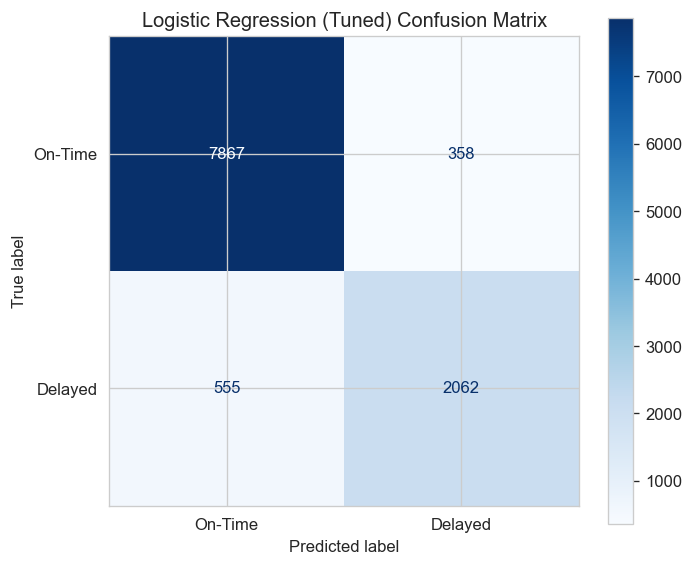

In [52]:
# ── 3.1c Logistic Regression: Confusion Matrix ──

fig, ax = plt.subplots(figsize=(6, 5))
y_pred_lr = lr_tuned.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['On-Time', 'Delayed'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Logistic Regression (Tuned) Confusion Matrix')
plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/lr_confusion_matrix.png', dpi=150)
plt.show()

In [53]:
# ── 3.1d Logistic Regression: Classification Report ──

print('Logistic Regression (Tuned) Classification Report')
print(classification_report(y_test, y_pred_lr, target_names=['On-Time', 'Delayed']))

Logistic Regression (Tuned) Classification Report
              precision    recall  f1-score   support

     On-Time       0.93      0.96      0.95      8225
     Delayed       0.85      0.79      0.82      2617

    accuracy                           0.92     10842
   macro avg       0.89      0.87      0.88     10842
weighted avg       0.91      0.92      0.91     10842


### 3.2 Random Forest (Non-linear Ensemble)

In [54]:
# ── 3.2a Random Forest: Baseline ──

rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_metrics = evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest')


-- Random Forest --
  Accuracy:  0.9169
  Precision: 0.8457
  Recall:    0.8021
  F1-Score:  0.8233
  ROC-AUC:   0.9445


In [55]:
# ── 3.2b Random Forest: Hyperparameter Tuning ──
# Use RandomizedSearchCV to tune RF hyperparameters
# rf_tuned_metrics = evaluate_model(rf_tuned, X_test, y_test, 'Random Forest (Tuned)')


# Random Forest pipeline tuning
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)

rf_tuned = rf_grid.best_estimator_

rf_tuned_metrics = evaluate_model(rf_tuned, X_test, y_test, 'Random Forest (Tuned)')

Best Random Forest parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}

-- Random Forest (Tuned) --
  Accuracy:  0.9172
  Precision: 0.8442
  Recall:    0.8055
  F1-Score:  0.8244
  ROC-AUC:   0.9462


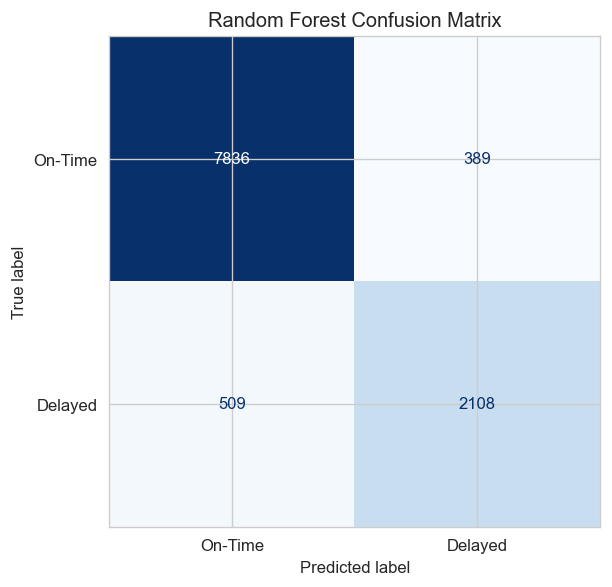

In [56]:
# Confusion Matrix for Random Forest Pipeline
y_pred_rf = rf_tuned.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['On-Time', 'Delayed'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()

fig.savefig(f'{RESULTS_DIR}/rf_confusion_matrix.png', dpi=150)
plt.show()

### 3.3 XGBoost (Non-linear Boosting)

XGBoost is a gradient-boosted decision tree ensemble. Each successive tree
is trained to correct the errors of the previous trees, producing a strong
non-linear model that typically outperforms a single decision tree or a
random forest on tabular data.

**Why XGBoost for this problem:**
- Handles non-linear feature interactions (e.g., late-evening flights from
  certain airports being especially delay-prone) without manual interaction
  features.
- Robust to feature scale (we still keep `StandardScaler` in the pipeline
  for consistency with the other models; it does not affect tree splits).
- Has well-developed regularization (`reg_alpha`, `reg_lambda`,
  `min_child_weight`) which helps avoid overfitting on the smaller
  delayed-class samples.

**Tuning approach:** The full XGBoost grid would have hundreds of
combinations, so we use `RandomizedSearchCV` with `n_iter=20` to sample
20 random combinations, which is much faster than full grid search and usually
finds a near-optimal configuration.

In [57]:
# ── 3.3a XGBoost: Baseline (Default Hyperparameters) ──
# Wrapped in an imblearn Pipeline so StandardScaler and SMOTE refit fresh
# inside each CV fold (see Step 2.8).
#
# Notes on the constructor args:
#   eval_metric='logloss' silences a deprecation warning in xgboost >=1.3
#   use_label_encoder=False is no longer needed in xgboost >=2.0 so omitted
#   tree_method='hist' uses faster histogram-based splitting (CPU)
#   n_jobs=-1 enables parallel tree building across cores

xgb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb_pipeline, X_test, y_test, 'XGBoost')


-- XGBoost --
  Accuracy:  0.9251
  Precision: 0.8912
  Recall:    0.7856
  F1-Score:  0.8351
  ROC-AUC:   0.9502


In [58]:
# ── 3.3b XGBoost: Hyperparameter Tuning (RandomizedSearchCV) ──
# RandomizedSearchCV samples n_iter random combinations from the grid
# instead of trying all of them. With 5 hyperparameters that each have
# multiple values, full grid search would be hundreds of fits; n_iter=20
# keeps tuning tractable while still exploring most of the space.
#
# Hyperparameters being tuned:
#   n_estimators:     number of boosting rounds (more = stronger but slower)
#   max_depth:        max depth of each tree (controls model complexity)
#   learning_rate:    shrinkage applied to each tree's contribution
#   subsample:        row sub-sampling per tree (regularization)
#   colsample_bytree: column sub-sampling per tree (regularization)

xgb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_dist = {
    'xgb__n_estimators':     [100, 200, 300],
    'xgb__max_depth':        [3, 5, 7, 9],
    'xgb__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample':        [0.7, 0.85, 1.0],
    'xgb__colsample_bytree': [0.7, 0.85, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print(f'Best XGBoost params: {xgb_search.best_params_}')
print(f'Best XGBoost CV F1:  {xgb_search.best_score_:.4f}')

xgb_tuned = xgb_search.best_estimator_
xgb_tuned_metrics = evaluate_model(xgb_tuned, X_test, y_test, 'XGBoost (Tuned)')

Best XGBoost params: {'xgb__subsample': 0.85, 'xgb__n_estimators': 300, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.7}
Best XGBoost CV F1:  0.8333

-- XGBoost (Tuned) --
  Accuracy:  0.9257
  Precision: 0.8973
  Recall:    0.7814
  F1-Score:  0.8354
  ROC-AUC:   0.9516


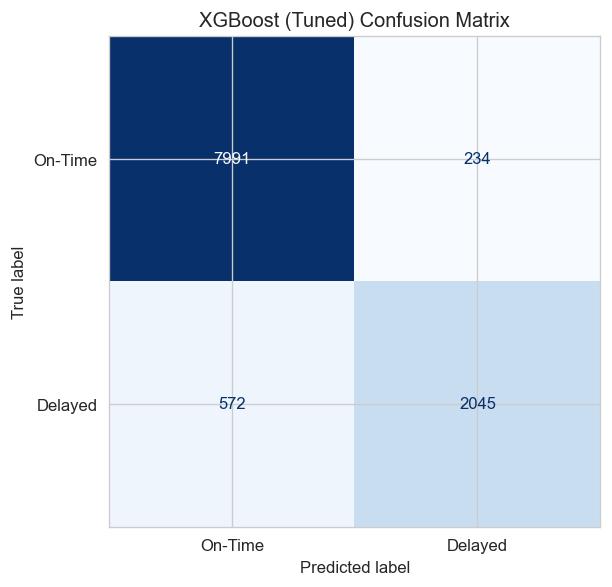


XGBoost (Tuned) Classification Report
              precision    recall  f1-score   support

     On-Time       0.93      0.97      0.95      8225
     Delayed       0.90      0.78      0.84      2617

    accuracy                           0.93     10842
   macro avg       0.92      0.88      0.89     10842
weighted avg       0.92      0.93      0.92     10842


In [59]:
# ── 3.3c XGBoost: Confusion Matrix & Classification Report ──

y_pred_xgb = xgb_tuned.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['On-Time', 'Delayed'])
disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')
ax.set_title('XGBoost (Tuned) Confusion Matrix')
plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/xgb_confusion_matrix.png', dpi=150)
plt.show()

print('\nXGBoost (Tuned) Classification Report')
print(classification_report(y_test, y_pred_xgb, target_names=['On-Time', 'Delayed']))

---
## 4. Model Comparison

We compare all three tuned models on the same test set using:
1. A summary table of test-set metrics
2. ROC curves overlaid on a single figure
3. A side-by-side bar chart of every metric

This is the comparison **with DepDelay included** - Section 5 repeats it without DepDelay to show the leakage impact.

In [60]:
# ── 4.1 Final Comparison Table ──
# Combine the metric dicts from each tuned model into a single DataFrame.

tuned_results = pd.DataFrame([lr_tuned_metrics, rf_tuned_metrics, xgb_tuned_metrics])
tuned_results = tuned_results.set_index('Model')
tuned_results_rounded = tuned_results.round(4)
print('Tuned model comparison (test set, WITH DepDelay):')
print(tuned_results_rounded.to_string())
tuned_results_rounded

Tuned model comparison (test set, WITH DepDelay):
                             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                      
Logistic Regression (Tuned)    0.9158     0.8521  0.7879    0.8187   0.9353
Random Forest (Tuned)          0.9172     0.8442  0.8055    0.8244   0.9462
XGBoost (Tuned)                0.9257     0.8973  0.7814    0.8354   0.9516


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (Tuned),0.9158,0.8521,0.7879,0.8187,0.9353
Random Forest (Tuned),0.9172,0.8442,0.8055,0.8244,0.9462
XGBoost (Tuned),0.9257,0.8973,0.7814,0.8354,0.9516


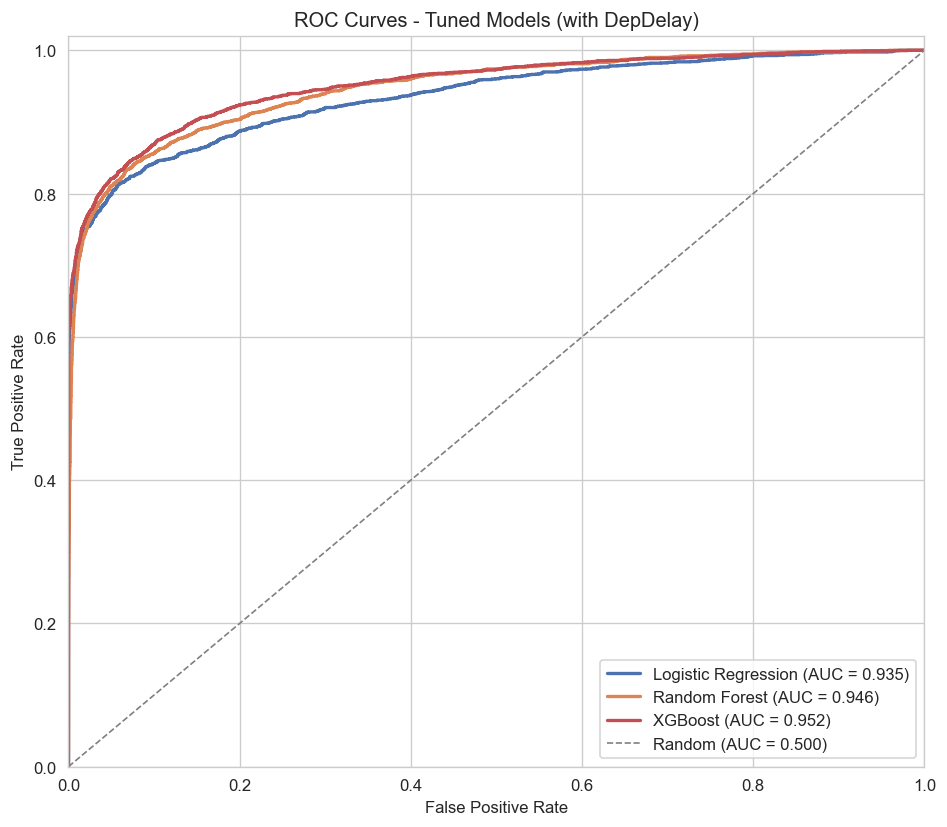

In [61]:
# ── 4.2 ROC Curves ──
# Overlay the ROC curve for each tuned model on a single figure.
# A model that just guesses would lie on the diagonal (AUC = 0.5).
# Higher curves (closer to top-left corner) = better discrimination.

fig, ax = plt.subplots(figsize=(8, 7))

models_for_roc = [
    ('Logistic Regression', lr_tuned, '#4c72b0'),
    ('Random Forest',       rf_tuned, '#dd8452'),
    ('XGBoost',             xgb_tuned, '#c44e52'),
]

for name, model, color in models_for_roc:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Diagonal reference line for a random classifier
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Tuned Models (with DepDelay)')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/roc_curves_with_depdelay.png', dpi=150)
plt.show()

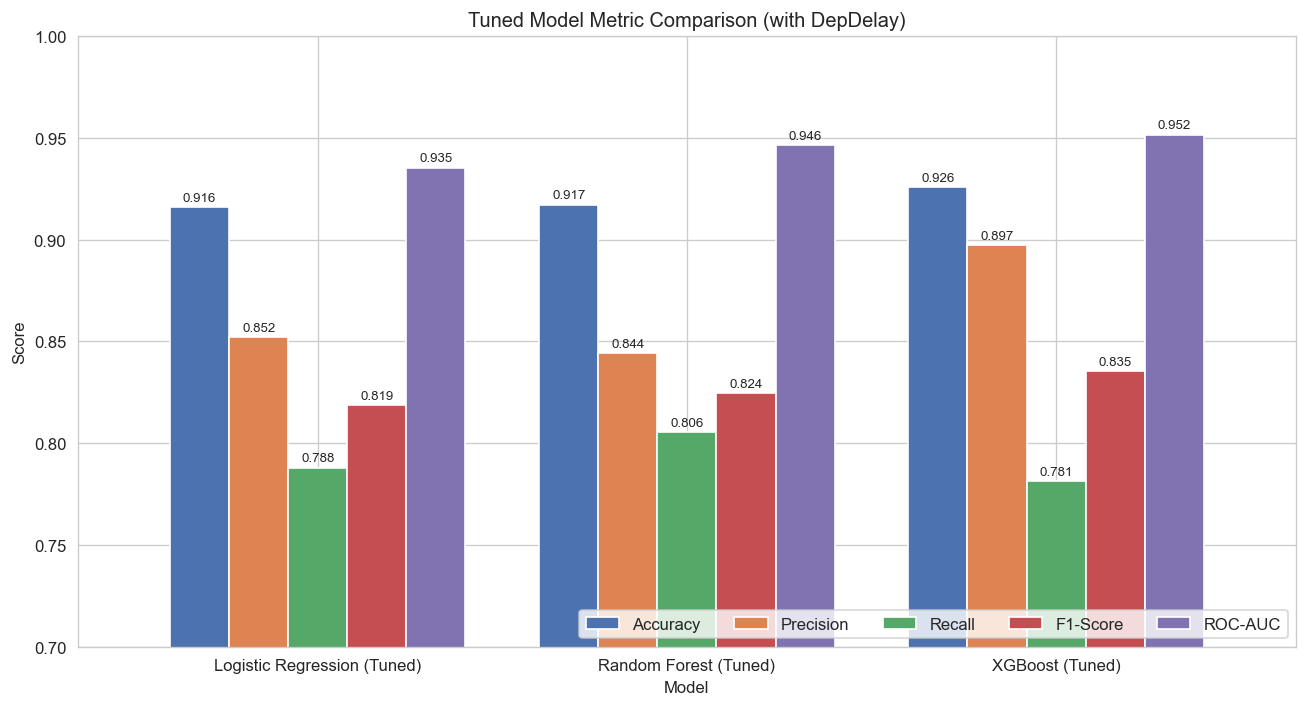

In [62]:
# ── 4.3 Metrics Bar Chart ──
# Side-by-side bars for each metric across the three tuned models.
# Visualizes the comparison table for the video presentation.

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = tuned_results[metric_cols]

fig, ax = plt.subplots(figsize=(11, 6))
plot_df.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b2'],
             edgecolor='white', width=0.8)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('Tuned Model Metric Comparison (with DepDelay)')
ax.set_xticklabels(plot_df.index, rotation=0)
ax.legend(loc='lower right', ncol=5)

# Annotate each bar with its value
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/metric_comparison_with_depdelay.png', dpi=150)
plt.show()

---
## 5. DepDelay Leakage Experiment

EDA showed `DepDelay` correlates 0.98 with `ArrDelay` - if a flight departs late, it almost certainly arrives late. Including `DepDelay` as a feature is **data leakage** in the real-world sense: at the time SkyWest would actually want a prediction (before the flight pushes back from the gate), `DepDelay` doesn't exist yet. You can't know how late departure was until departure has already happened.

This section repeats the experiment with `DepDelay` removed to show:
1. How much of the previous F1 was being driven by leakage
2. What performance the **realistic** model (predicting arrival delay before departure) actually achieves

We re-use the tuned hyperparameters from Section 3 (cloning each tuned pipeline) and refit on the leakage-free training set. This makes the comparison apples-to-apples - same hyperparameters, same preprocessing, only the feature set differs.

In [63]:
# ── 5.1 Rebuild features without DepDelay ──
# Drop the DepDelay column from the existing train/test split. We use the
# SAME rows as before so that the comparison is fair (same train/test split,
# same preprocessing, same hyperparameters - only the feature set differs).

X_train_nd = X_train.drop(columns=['DepDelay'])
X_test_nd  = X_test.drop(columns=['DepDelay'])

print(f'Features WITH DepDelay:    {X_train.shape[1]} columns')
print(f'Features WITHOUT DepDelay: {X_train_nd.shape[1]} columns')
print(f'\nDropped column: DepDelay')

Features WITH DepDelay:    191 columns
Features WITHOUT DepDelay: 190 columns

Dropped column: DepDelay


In [64]:
# ── 5.2 Train models without DepDelay ──
# clone() returns an unfitted copy of each pipeline with the same hyperparameters
# (the ones GridSearch/RandomizedSearch picked in Section 3). Refitting these
# clones on X_train_nd gives us the same models, trained on leakage-free data.

from sklearn.base import clone

# LR - clone the tuned pipeline and refit
lr_no_dep = clone(lr_tuned)
lr_no_dep.fit(X_train_nd, y_train)
lr_no_dep_metrics = evaluate_model(lr_no_dep, X_test_nd, y_test, 'LR (no DepDelay)')

# RF - same
rf_no_dep = clone(rf_tuned)
rf_no_dep.fit(X_train_nd, y_train)
rf_no_dep_metrics = evaluate_model(rf_no_dep, X_test_nd, y_test, 'RF (no DepDelay)')

# XGBoost - same
xgb_no_dep = clone(xgb_tuned)
xgb_no_dep.fit(X_train_nd, y_train)
xgb_no_dep_metrics = evaluate_model(xgb_no_dep, X_test_nd, y_test, 'XGBoost (no DepDelay)')


-- LR (no DepDelay) --
  Accuracy:  0.6071
  Precision: 0.3245
  Recall:    0.5804
  F1-Score:  0.4163
  ROC-AUC:   0.6320

-- RF (no DepDelay) --
  Accuracy:  0.7591
  Precision: 0.5012
  Recall:    0.4020
  F1-Score:  0.4461
  ROC-AUC:   0.7229

-- XGBoost (no DepDelay) --
  Accuracy:  0.7922
  Precision: 0.6226
  Recall:    0.3531
  F1-Score:  0.4506
  ROC-AUC:   0.7515


Leakage comparison (test-set metrics):
              Model         Scenario  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    with DepDelay    0.9158     0.8521  0.7879    0.8187   0.9353
Logistic Regression without DepDelay    0.6071     0.3245  0.5804    0.4163   0.6320
      Random Forest    with DepDelay    0.9172     0.8442  0.8055    0.8244   0.9462
      Random Forest without DepDelay    0.7591     0.5012  0.4020    0.4461   0.7229
            XGBoost    with DepDelay    0.9257     0.8973  0.7814    0.8354   0.9516
            XGBoost without DepDelay    0.7922     0.6226  0.3531    0.4506   0.7515


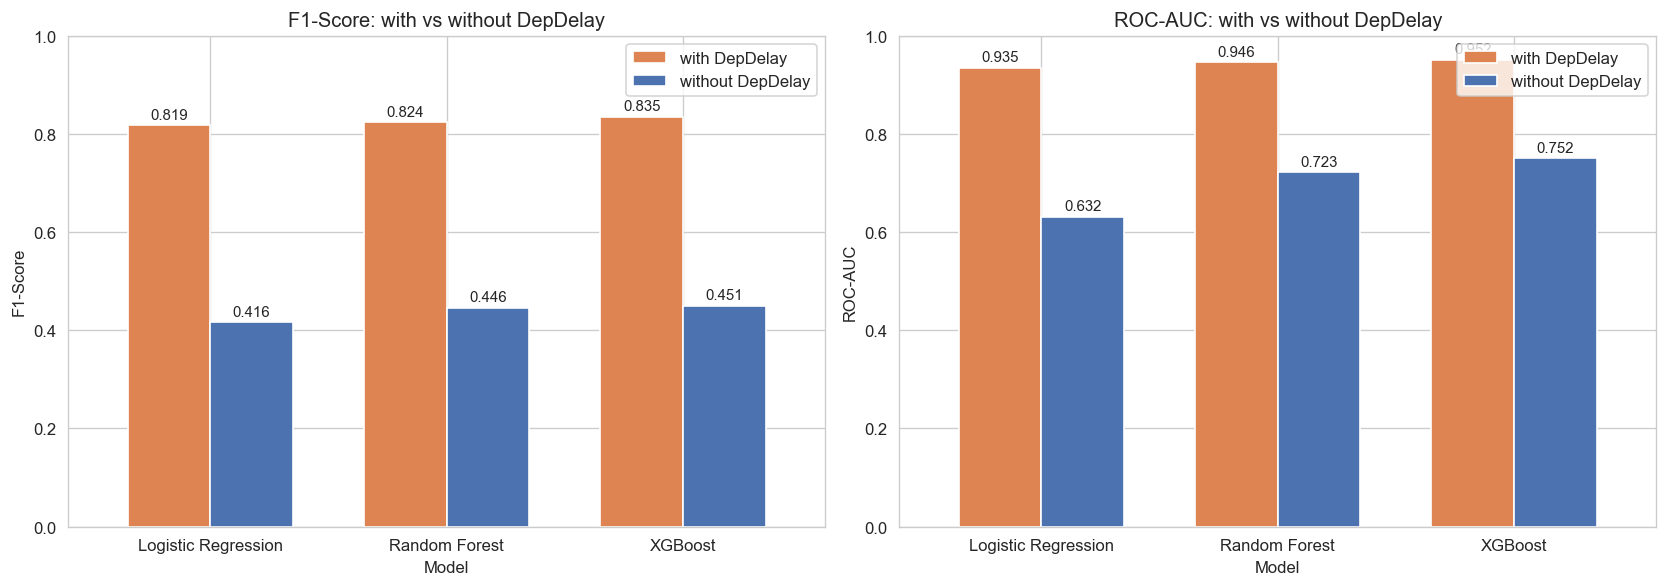


F1 drop when DepDelay is removed (the leakage impact):
  Logistic Regression     0.819 → 0.416  (drop = 0.402, 49.2%)
  Random Forest           0.824 → 0.446  (drop = 0.378, 45.9%)
  XGBoost                 0.835 → 0.451  (drop = 0.385, 46.1%)


In [65]:
# ── 5.3 Compare with vs without DepDelay ──
# Side-by-side table and bar chart of F1 / ROC-AUC across the two scenarios.

# Build the comparison DataFrame: one row per (model, scenario)
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Scenario': 'with DepDelay',    **{k: v for k, v in lr_tuned_metrics.items() if k != 'Model'}},
    {'Model': 'Logistic Regression', 'Scenario': 'without DepDelay', **{k: v for k, v in lr_no_dep_metrics.items() if k != 'Model'}},
    {'Model': 'Random Forest',       'Scenario': 'with DepDelay',    **{k: v for k, v in rf_tuned_metrics.items() if k != 'Model'}},
    {'Model': 'Random Forest',       'Scenario': 'without DepDelay', **{k: v for k, v in rf_no_dep_metrics.items() if k != 'Model'}},
    {'Model': 'XGBoost',             'Scenario': 'with DepDelay',    **{k: v for k, v in xgb_tuned_metrics.items() if k != 'Model'}},
    {'Model': 'XGBoost',             'Scenario': 'without DepDelay', **{k: v for k, v in xgb_no_dep_metrics.items() if k != 'Model'}},
])

print('Leakage comparison (test-set metrics):')
print(comparison.round(4).to_string(index=False))

# F1 drop visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pivot for grouped bar chart on F1
f1_pivot = comparison.pivot(index='Model', columns='Scenario', values='F1-Score')
f1_pivot = f1_pivot[['with DepDelay', 'without DepDelay']]  # column order
f1_pivot.plot(kind='bar', ax=axes[0], color=['#dd8452', '#4c72b0'], edgecolor='white', width=0.7)
axes[0].set_title('F1-Score: with vs without DepDelay')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(f1_pivot.index, rotation=0)
axes[0].legend(title='')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Same for ROC-AUC
auc_pivot = comparison.pivot(index='Model', columns='Scenario', values='ROC-AUC')
auc_pivot = auc_pivot[['with DepDelay', 'without DepDelay']]
auc_pivot.plot(kind='bar', ax=axes[1], color=['#dd8452', '#4c72b0'], edgecolor='white', width=0.7)
axes[1].set_title('ROC-AUC: with vs without DepDelay')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(auc_pivot.index, rotation=0)
axes[1].legend(title='')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', fontsize=9, padding=2)

plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/leakage_comparison.png', dpi=150)
plt.show()

# Print the F1 drop magnitude per model
print('\nF1 drop when DepDelay is removed (the leakage impact):')
for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    with_d    = f1_pivot.loc[model, 'with DepDelay']
    without_d = f1_pivot.loc[model, 'without DepDelay']
    drop      = with_d - without_d
    pct_drop  = drop / with_d * 100
    print(f'  {model:22s}  {with_d:.3f} → {without_d:.3f}  '
          f'(drop = {drop:.3f}, {pct_drop:.1f}%)')

---
## 6. Feature Importance and Final Summary

We extract feature importances from the tree-based models (Random Forest and XGBoost) to understand **which features are actually driving predictions** - beyond just the obvious DepDelay leakage.

We use the **leakage-free models** from Section 5 (`rf_no_dep`, `xgb_no_dep`) so the importances reflect what matters for the realistic prediction scenario, not what matters when the answer is being read off DepDelay.

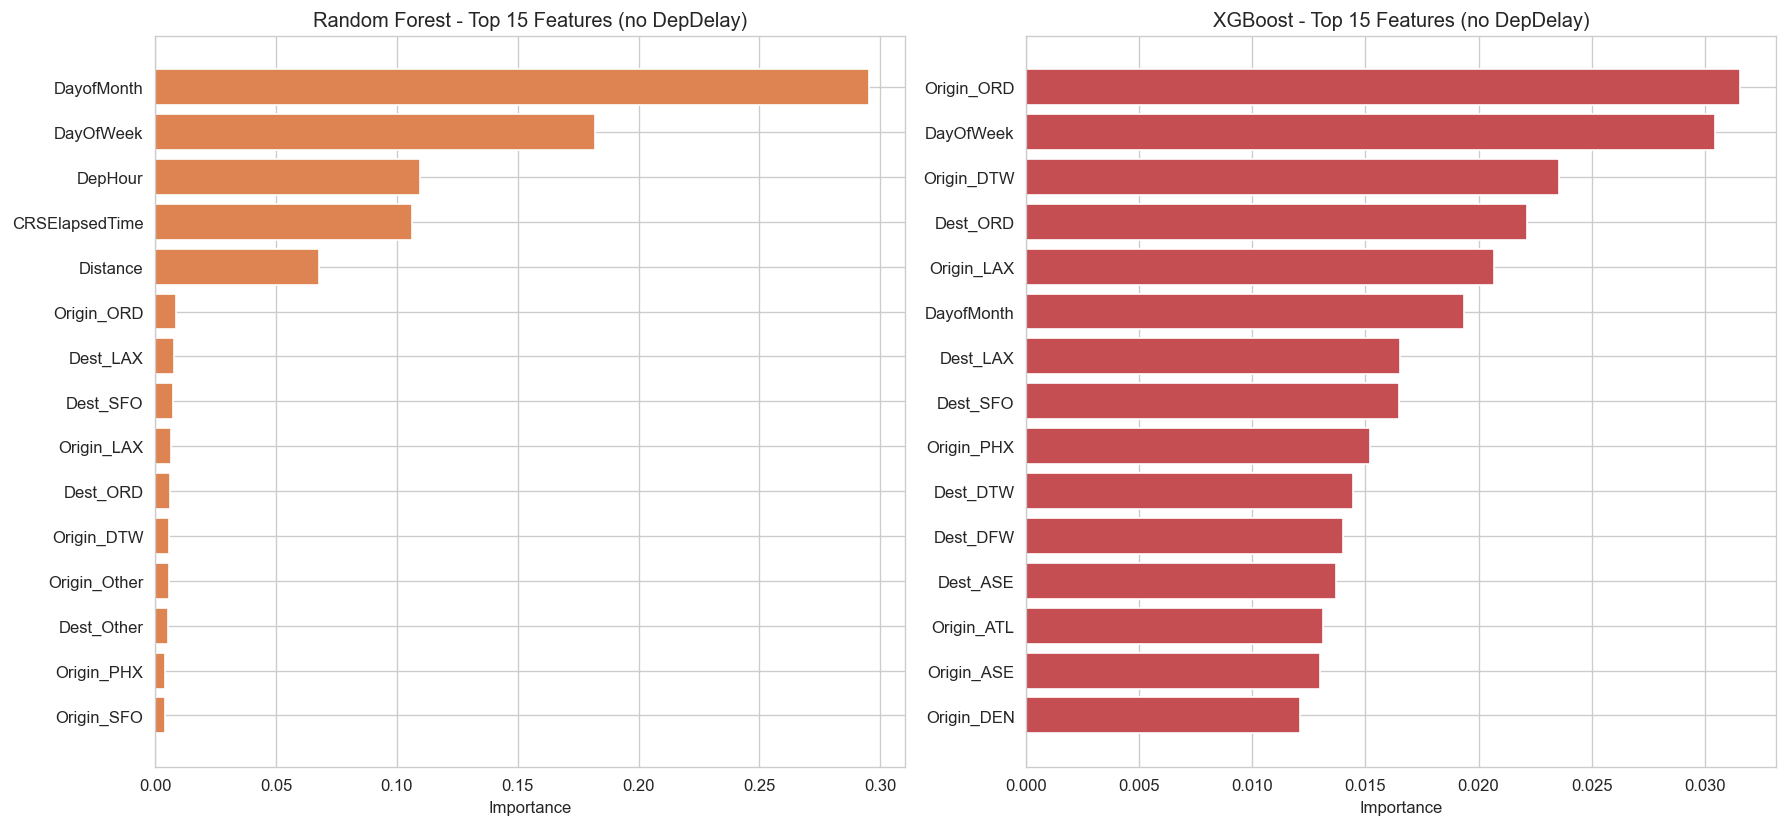


Top 10 features - Random Forest:
DayofMonth        0.2955
DayOfWeek         0.1820
DepHour           0.1094
CRSElapsedTime    0.1063
Distance          0.0677
Origin_ORD        0.0088
Dest_LAX          0.0079
Dest_SFO          0.0074
Origin_LAX        0.0065
Dest_ORD          0.0059

Top 10 features - XGBoost:
Origin_ORD    0.0316
DayOfWeek     0.0305
Origin_DTW    0.0235
Dest_ORD      0.0221
Origin_LAX    0.0207
DayofMonth    0.0194
Dest_LAX      0.0165
Dest_SFO      0.0165
Origin_PHX    0.0152
Dest_DTW      0.0145


In [66]:
# ── 6.1 Feature Importance ──
# RF and XGBoost both expose .feature_importances_ on the underlying estimator.
# We pull from the no-DepDelay pipelines so the importance is meaningful in
# the realistic prediction setting.

# Pull the inner estimator out of each pipeline
rf_inner  = rf_no_dep.named_steps['rf']
xgb_inner = xgb_no_dep.named_steps['xgb']

feature_names = X_train_nd.columns.tolist()

rf_imp  = pd.Series(rf_inner.feature_importances_,  index=feature_names).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_inner.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot the top 15 features for each model side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top_n = 15

rf_top = rf_imp.head(top_n)[::-1]
axes[0].barh(rf_top.index, rf_top.values, color='#dd8452')
axes[0].set_title(f'Random Forest - Top {top_n} Features (no DepDelay)')
axes[0].set_xlabel('Importance')

xgb_top = xgb_imp.head(top_n)[::-1]
axes[1].barh(xgb_top.index, xgb_top.values, color='#c44e52')
axes[1].set_title(f'XGBoost - Top {top_n} Features (no DepDelay)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=150)
plt.show()

print('\nTop 10 features - Random Forest:')
print(rf_imp.head(10).round(4).to_string())

print('\nTop 10 features - XGBoost:')
print(xgb_imp.head(10).round(4).to_string())

## 6.2 Final Summary

### Best model
XGBoost (tuned) was the best model in both scenarios:
- With DepDelay: F1 = 0.835, ROC-AUC = 0.952
- Without DepDelay: F1 = 0.451, ROC-AUC = 0.752

The ranking was XGBoost first, Random Forest second, Logistic Regression third. This is what we expected. A boosting model usually beats a bagging model, and both usually beat a simple linear model.

### Tuning barely helped
For all three models, tuning the hyperparameters only improved F1 by less than 0.01. This tells us the default settings were already close to optimal. Most of the prediction quality came from the preprocessing steps (balancing the classes with SMOTE, engineering the DepHour feature, one-hot encoding the airports), not from picking a fancy tree depth or regularization strength.

### The DepDelay leakage story (the main finding)
When we removed DepDelay from the features, F1 dropped by about 46 to 49 percent across all three models:
- Logistic Regression: 0.819 to 0.416 (drop of 49.2%)
- Random Forest: 0.824 to 0.446 (drop of 45.9%)
- XGBoost: 0.835 to 0.451 (drop of 46.1%)

Almost half of every model's score was coming from data leakage. The EDA showed that DepDelay correlates 0.98 with ArrDelay, so the model was basically reading the answer off the DepDelay column.

In the real world, SkyWest cannot use DepDelay as a feature. At the moment they actually want a prediction (before the flight pushes back from the gate), DepDelay does not exist yet. You cannot know how late a departure was until the departure has already happened.

The numbers without DepDelay are the ones that matter. They show the true difficulty of predicting arrival delay using only information that is known before the flight leaves. F1 around 0.45 is what is realistically achievable on this problem.

### What the leakage-free models actually use
The feature importance plots in 6.1 show that Random Forest and XGBoost weight features quite differently.

Random Forest top features:
- DayofMonth (0.30)
- DayOfWeek (0.18)
- DepHour (0.11)
- CRSElapsedTime (0.11)
- Distance (0.07)

XGBoost top features:
- Origin_ORD (Chicago O'Hare)
- DayOfWeek
- Origin_DTW (Detroit)
- Dest_ORD, Dest_LAX, Dest_SFO
- DayofMonth

The two models tell different stories.

Random Forest leans very heavily on DayofMonth (30 percent of its total importance). This is concerning because our dataset only covers January 2024. So DayofMonth is basically letting the model memorize "January 12 was a bad day" or "January 25 was a good day". That is not a generalizable pattern. It is the model learning specific weather events that happened on specific calendar days. Outside of January 2024, this signal would not work.

XGBoost is healthier on this front. It spreads its importance across major airport hubs (Chicago, Detroit, LAX, SFO, Phoenix). Hub congestion is a real and persistent driver of delays that would still apply outside our training month, so this is a much more transferable pattern.

### Limitations
1. **No weather data.** The dataset has a WeatherDelay column, but it gets filled in after the flight lands, not before. Joining with hourly weather observations from each airport (for example METAR data) would probably be the single biggest improvement.
2. **Only one month of data.** With just January 2024, we cannot learn seasonal patterns. A full year would let the model see summer thunderstorm season, holiday congestion, and so on. It would also stop Random Forest from overfitting to specific January dates.
3. **No upstream-flight features.** Most cascading delays come from the previous leg of the same aircraft. A "previous flight delay" feature would partly fill the gap left by removing DepDelay.
4. **SkyWest only.** The model is specific to one regional carrier. To use it for other airlines we would need to retrain.

### Recommendation for SkyWest
The leakage-free XGBoost model is the one to deploy. F1 of 0.45 sounds low compared to the 0.83 we got with DepDelay, but it reflects the true difficulty of the problem.

The model is conservative. When it predicts a delay, it is right about 62 percent of the time (precision 0.62). But it only catches about 35 percent of the actual delays (recall 0.35). It would rather miss a real delay than cry wolf.

For SkyWest's use case (proactive passenger rebooking, crew scheduling) this conservative profile is actually what they want. Acting on a false alarm is expensive (you have to rebook passengers, call in extra crew), while a missed delay just means business as usual until the delay shows up. So a model that only flags the delays it is very confident about is more useful than one that flags everything and forces SkyWest to ignore most alerts.